✅ Saved Table: RQ1_Baseline_Table.csv

            Model      MAE     RMSE    R2
Linear Regression 24737.94 28586.97 -0.00
    Decision Tree 32833.45 40315.28 -0.99
             k-NN 26045.05 31020.99 -0.18

✅ Saved Figure: RQ1_Baseline_Figure.pdf


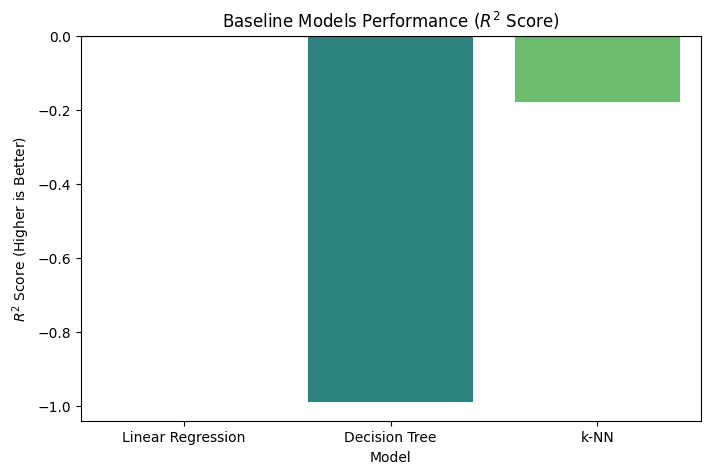

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Automatically find the dataset file in the Kaggle environment
data_path = "/kaggle/input/datasets/imranalishahh/marketing-and-product-performance-dataset"
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.csv') or filename.endswith('.xlsx'):
            data_path = os.path.join(dirname, filename)
            break

# 2. Load Data
if data_path.endswith('.csv'):
    df = pd.read_csv(data_path)
else:
    df = pd.read_excel(data_path)

target = 'Revenue_Generated'

# Drop rows where the target itself is missing
df = df.dropna(subset=[target])

# Separate features (X) and target (y)
X = df.drop(columns=[target])
y = df[target]

# Identify categorical and numerical columns automatically
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'category']).columns

# 3. Create a minimal preprocessing pipeline for the baselines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 4. Split data into Training and Testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Initialize the Baseline Models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "k-NN": KNeighborsRegressor(n_neighbors=5)
}

results = []

# 6. Train and Evaluate each model
for name, model in models.items():
    # Bundle preprocessing and modeling in a pipeline
    clf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('model', model)])
    
    # Train the model
    clf.fit(X_train, y_train)
    
    # Make predictions
    y_pred = clf.predict(X_test)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    # Save the results
    results.append({
        "Model": name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R2": round(r2, 2)
    })

# Convert results to a pandas DataFrame
results_df = pd.DataFrame(results)

# --- 7. SAVE TABLE AS CSV ---
results_df.to_csv('RQ1_Baseline_Table.csv', index=False)
print("✅ Saved Table: RQ1_Baseline_Table.csv\n")
print(results_df.to_string(index=False))

# --- 8. GENERATE AND SAVE FIGURE AS PDF ---
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='R2', data=results_df, palette='viridis', hue='Model', legend=False)
plt.title('Baseline Models Performance ($R^2$ Score)')
plt.ylabel('$R^2$ Score (Higher is Better)')

# Adjust Y-axis just in case scores are low or negative
plt.axhline(0, color='black', linewidth=0.8) 

# Save to PDF
plt.savefig('RQ1_Baseline_Figure.pdf', bbox_inches='tight')
print("\n✅ Saved Figure: RQ1_Baseline_Figure.pdf")
plt.show()